# 01 — Data Loading & Preprocessing
**CMPE 255 — Student Dropout Prediction Project**

This notebook covers:
- Loading the UCI dataset (id 697)
- Data inspection and schema understanding
- Encoding and transformation
- Normalization / standardization
- Class imbalance analysis
- Train/test split
- Saving preprocessed data

In [1]:
# Install dependencies (run once in Colab)
# !pip install ucimlrepo imbalanced-learn xgboost mlxtend

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

os.makedirs('../results/figures', exist_ok=True)
os.makedirs('../results/tables', exist_ok=True)

pd.set_option('display.max_columns', 40)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/duylam1407/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  Fi

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.4.4 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Libraries loaded successfully.


## 1. Load the Dataset

In [3]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (4424, 37)
Columns: ['Marital Status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Previous qualification (grade)', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Admission grade', 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation ra

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## 2. Data Inspection

In [4]:
# Basic info
print(df.info())
print('\n--- Missing Values ---')
print(df.isnull().sum().sum(), 'total missing values')
print('\n--- Target Distribution ---')
print(df['Target'].value_counts())
print(df['Target'].value_counts(normalize=True).round(3))

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [5]:
# Descriptive statistics
df.describe().round(2)

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,1.18,18.67,1.73,8856.64,0.89,4.58,132.61,1.87,19.56,22.28,10.96,11.03,126.98,0.55,0.01,0.11,0.88,0.35,0.25,23.27,0.02,0.71,6.27,8.30,4.71,10.64,0.14,0.54,6.23,8.06,4.44,10.23,0.15,11.57,1.23,0.00
std,0.61,17.48,1.31,2063.57,0.31,10.22,13.19,6.91,15.60,15.34,26.42,25.26,14.48,0.50,0.11,0.32,0.32,0.48,0.43,7.59,0.16,2.36,2.48,4.18,3.09,4.84,0.69,1.92,2.20,3.95,3.01,5.21,0.75,2.66,1.38,2.27
min,1.00,1.00,0.00,33.00,0.00,1.00,95.00,1.00,1.00,1.00,0.00,0.00,95.00,0.00,0.00,0.00,0.00,0.00,0.00,17.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,7.60,-0.80,-4.06
25%,1.00,1.00,1.00,9085.00,1.00,1.00,125.00,1.00,2.00,3.00,4.00,4.00,117.90,0.00,0.00,0.00,1.00,0.00,0.00,19.00,0.00,0.00,5.00,6.00,3.00,11.00,0.00,0.00,5.00,6.00,2.00,10.75,0.00,9.40,0.30,-1.70
50%,1.00,17.00,1.00,9238.00,1.00,1.00,133.10,1.00,19.00,19.00,5.00,7.00,126.10,1.00,0.00,0.00,1.00,0.00,0.00,20.00,0.00,0.00,6.00,8.00,5.00,12.29,0.00,0.00,6.00,8.00,5.00,12.20,0.00,11.10,1.40,0.32
75%,1.00,39.00,2.00,9556.00,1.00,1.00,140.00,1.00,37.00,37.00,9.00,9.00,134.80,1.00,0.00,0.00,1.00,1.00,0.00,25.00,0.00,0.00,7.00,10.00,6.00,13.40,0.00,0.00,7.00,10.00,6.00,13.33,0.00,13.90,2.60,1.79
max,6.00,57.00,9.00,9991.00,1.00,43.00,190.00,109.00,44.00,44.00,194.00,195.00,190.00,1.00,1.00,1.00,1.00,1.00,1.00,70.00,1.00,20.00,26.00,45.00,26.00,18.88,12.00,19.00,23.00,33.00,20.00,18.57,12.00,16.20,3.70,3.51


## 3. Data Preprocessing

In [6]:
# Encode the target variable
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target_encoded'] = df['Target'].map(target_map)
print('Target encoding:', target_map)

Target encoding: {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}


In [7]:
# Feature type analysis — identify categorical vs continuous features
# Features with <= 15 unique integer values are likely categorical encodings
X_temp = df.drop(columns=['Target', 'Target_encoded'])
CATEGORICAL_THRESHOLD = 15

cat_cols = [col for col in X_temp.columns if X_temp[col].nunique() <= CATEGORICAL_THRESHOLD]
num_cols = [col for col in X_temp.columns if X_temp[col].nunique() > CATEGORICAL_THRESHOLD]

print(f'Feature Type Summary (threshold: ≤{CATEGORICAL_THRESHOLD} unique values = categorical)')
print('=' * 60)
print(f'\nCategorical-encoded integer features ({len(cat_cols)}):')
for col in cat_cols:
    print(f'  {col}: {X_temp[col].nunique()} unique values')
print(f'\nContinuous numeric features ({len(num_cols)}):')
for col in num_cols:
    print(f'  {col}: {X_temp[col].nunique()} unique values  '
          f'[{X_temp[col].min():.1f} – {X_temp[col].max():.1f}]')

Feature Type Summary (threshold: ≤15 unique values = categorical)

Categorical-encoded integer features (15):
  Marital Status: 6 unique values
  Application order: 8 unique values
  Daytime/evening attendance: 2 unique values
  Displaced: 2 unique values
  Educational special needs: 2 unique values
  Debtor: 2 unique values
  Tuition fees up to date: 2 unique values
  Gender: 2 unique values
  Scholarship holder: 2 unique values
  International: 2 unique values
  Curricular units 1st sem (without evaluations): 11 unique values
  Curricular units 2nd sem (without evaluations): 10 unique values
  Unemployment rate: 10 unique values
  Inflation rate: 9 unique values
  GDP: 10 unique values

Continuous numeric features (21):
  Application mode: 18 unique values  [1.0 – 57.0]
  Course: 17 unique values  [33.0 – 9991.0]
  Previous qualification: 17 unique values  [1.0 – 43.0]
  Previous qualification (grade): 101 unique values  [95.0 – 190.0]
  Nacionality: 21 unique values  [1.0 – 109.0]
 

--- Class Distribution ---
  Dropout   : 1421  (32.1%)
  Enrolled  :  794  (17.9%)
  Graduate  : 2209  (49.9%)

Imbalance ratio (Graduate / Enrolled): 2.78x
Note: Moderate imbalance — use stratified splits and macro F1 for evaluation.


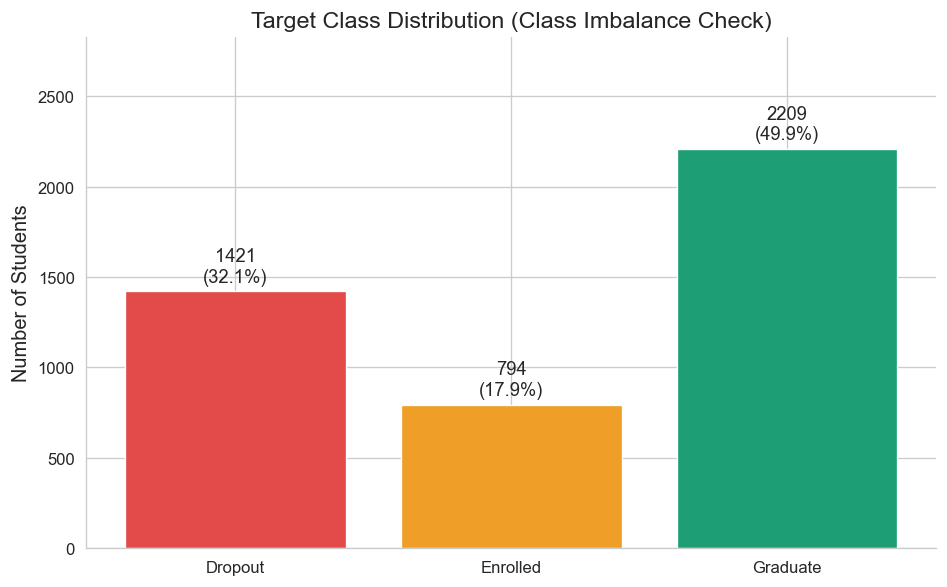

In [8]:
# Class imbalance analysis and visualization
COLORS = {'Dropout': '#E24B4A', 'Enrolled': '#EF9F27', 'Graduate': '#1D9E75'}
ORDER = ['Dropout', 'Enrolled', 'Graduate']

counts = df['Target'].value_counts().reindex(ORDER)
total = len(df)

print('--- Class Distribution ---')
for cls, cnt in counts.items():
    print(f'  {cls:10s}: {cnt:4d}  ({cnt / total * 100:.1f}%)')
print(f'\nImbalance ratio (Graduate / Enrolled): {counts["Graduate"] / counts["Enrolled"]:.2f}x')
print('Note: Moderate imbalance — use stratified splits and macro F1 for evaluation.')

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(counts.index, counts.values,
              color=[COLORS[c] for c in counts.index],
              edgecolor='white', linewidth=0.8)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11)
ax.set_ylabel('Number of Students', fontsize=12)
ax.set_title('Target Class Distribution (Class Imbalance Check)', fontsize=14)
ax.set_ylim(0, counts.max() * 1.28)
sns.despine()
plt.tight_layout()
fig.savefig('../results/figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Separate features and target
X = df.drop(columns=['Target', 'Target_encoded'])
y = df['Target_encoded']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'\nTarget distribution:\n{y.value_counts().sort_index()}')

Features shape: (4424, 36)
Target shape: (4424,)

Target distribution:
Target_encoded
0    1421
1     794
2    2209
Name: count, dtype: int64


In [10]:
# Normalize numeric features
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print('Features normalized with StandardScaler.')
X_scaled.describe().round(2)

Features normalized with StandardScaler.


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00,4424.00
mean,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.29,-1.01,-1.32,-4.28,-2.86,-0.35,-2.85,-0.13,-1.19,-1.39,-0.41,-0.44,-2.21,-1.10,-0.11,-0.36,-2.72,-0.74,-0.57,-0.83,-0.16,-0.30,-2.53,-1.99,-1.52,-2.20,-0.20,-0.28,-2.84,-2.04,-1.47,-1.96,-0.20,-1.49,-1.47,-1.79
25%,-0.29,-1.01,-0.55,0.11,0.35,-0.35,-0.58,-0.13,-1.13,-1.26,-0.26,-0.28,-0.63,-1.10,-0.11,-0.36,0.37,-0.74,-0.57,-0.56,-0.16,-0.30,-0.51,-0.55,-0.55,0.07,-0.20,-0.28,-0.56,-0.52,-0.81,0.10,-0.20,-0.81,-0.67,-0.75
50%,-0.29,-0.10,-0.55,0.18,0.35,-0.35,0.04,-0.13,-0.04,-0.21,-0.23,-0.16,-0.06,0.91,-0.11,-0.36,0.37,-0.74,-0.57,-0.43,-0.16,-0.30,-0.11,-0.07,0.09,0.34,-0.20,-0.28,-0.11,-0.02,0.19,0.38,-0.20,-0.18,0.12,0.14
75%,-0.29,1.16,0.21,0.34,0.35,-0.35,0.56,-0.13,1.12,0.96,-0.07,-0.08,0.54,0.91,-0.11,-0.36,0.37,1.36,-0.57,0.23,-0.16,-0.30,0.29,0.41,0.42,0.57,-0.20,-0.28,0.35,0.49,0.52,0.60,-0.20,0.88,0.99,0.79
max,7.96,2.19,5.54,0.55,0.35,3.76,4.35,15.49,1.57,1.42,6.93,7.28,4.35,0.91,9.26,2.79,0.37,1.36,1.74,6.16,6.26,8.17,7.96,8.78,6.88,1.70,17.17,9.62,7.64,6.32,5.16,1.60,15.72,1.74,1.79,1.55


## 4. Train/Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set:     {X_test.shape[0]} samples')
print(f'\nTraining target distribution:\n{y_train.value_counts().sort_index()}')
print(f'\nTest target distribution:\n{y_test.value_counts().sort_index()}')

Training set: 3539 samples
Test set:     885 samples

Training target distribution:
Target_encoded
0    1137
1     635
2    1767
Name: count, dtype: int64

Test target distribution:
Target_encoded
0    284
1    159
2    442
Name: count, dtype: int64


## 5. Save Preprocessed Data
Save for use in the next notebooks.

In [12]:
# Save for downstream notebooks
df.to_csv('../data/raw/data.csv', index=False)
X_train.to_csv('../data/X_train.csv', index=False)
X_test.to_csv('../data/X_test.csv', index=False)
y_train.to_csv('../data/y_train.csv', index=False)
y_test.to_csv('../data/y_test.csv', index=False)

# Save unscaled features for EDA notebook
X.to_csv('../data/X_unscaled.csv', index=False)

# Save full scaled dataset + labels for cross-validation in notebook 03
X_scaled.to_csv('../data/X_scaled_full.csv', index=False)
y.to_csv('../data/y_full.csv', index=False)

print('All data saved:')
print('  data/raw/data.csv       — full dataset with Target')
print('  data/X_train.csv        — scaled training features')
print('  data/X_test.csv         — scaled test features')
print('  data/y_train.csv        — training labels (encoded)')
print('  data/y_test.csv         — test labels (encoded)')
print('  data/X_unscaled.csv     — unscaled features (for EDA)')
print('  data/X_scaled_full.csv  — full scaled dataset (for CV)')
print('  data/y_full.csv         — full labels (for CV)')

All data saved:
  data/raw/data.csv       — full dataset with Target
  data/X_train.csv        — scaled training features
  data/X_test.csv         — scaled test features
  data/y_train.csv        — training labels (encoded)
  data/y_test.csv         — test labels (encoded)
  data/X_unscaled.csv     — unscaled features (for EDA)
  data/X_scaled_full.csv  — full scaled dataset (for CV)
  data/y_full.csv         — full labels (for CV)
